In [1]:
'''
Here in this data set,
Under diploid single locus case,
Once we modelled sex, 
Instead of assuming the effect of modifier mutation additive, we changed their effect to be dominant (thus with only 1 copy
of the modifier mutation they can change the mutation rate by 90%) and recessive (thus only with 2 copies of the modifier 
mutation they can change the mutation rate by 90%). 



Here N = 2000 and assuming 1% mutations are beneficial.Simulate for 20K generations.
Tried Mitosis, RM, RME10 with mitosis, RME100 with mitosis, RM E1K with mitosis and RM E10K with mitosis.

'''

'\nHere in this data set,\nUnder diploid single locus case,\nOnce we modelled sex, \nInstead of assuming the effect of modifier mutation additive, we changed their effect to be dominant (thus with only 1 copy\nof the modifier mutation they can change the mutation rate by 90%) and recessive (thus only with 2 copies of the modifier \nmutation they can change the mutation rate by 90%). \n\nThis is to check whether the segregation process during sex causes the difference between diploid and haploid with L = 200.\n\nHere N = 2000 and assuming 1% mutations are beneficial.Simulate for 20K generations.\nTried Mitosis, RM, RME10 with mitosis, RME100 with mitosis, RM E1K with mitosis and RM E10K with mitosis.\n\n'

In [2]:
from __future__ import division
import numpy as np
from scipy import stats
import scipy.spatial as spa
import numpy.random as rnd
import copy
import time
import pandas as pd
import math
import pickle
import seaborn as sns
import os

In [4]:
def get_data1(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    total_soma_mu_bene_mean = []
    total_soma_mu_bene_std = []

    total_soma_mu_dele_mean = []
    total_soma_mu_dele_std = []
    
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
        soma_mu_bene_mean = []
        soma_mu_bene_std = []

        soma_mu_dele_mean = []
        soma_mu_dele_std = []
            
        
        fit_mean.extend(list(pd.Series(f.PopMeanFit_Mean,dtype=float)))
        fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
    
        soma_mu_bene_mean.extend(list(pd.Series(f.SomaMu_Bene_Mean,dtype=float)))
        soma_mu_bene_std.extend(list(pd.Series(f.SomaMu_Bene_Std,dtype=float)))

        soma_mu_dele_mean.extend(list(pd.Series(f.SomaMu_Dele_Mean,dtype=float)))
        soma_mu_dele_std.extend(list(pd.Series(f.SomaMu_Dele_Std,dtype=float)))
        
        
        
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        total_soma_mu_bene_mean.append(soma_mu_bene_mean)
        total_soma_mu_bene_std.append(soma_mu_bene_std)  

        total_soma_mu_dele_mean.append(soma_mu_dele_mean)
        total_soma_mu_dele_std.append(soma_mu_dele_std)
        
        
        
    return total_fit_mean, total_fit_std, total_soma_mu_bene_mean, total_soma_mu_bene_std, \
total_soma_mu_dele_mean, total_soma_mu_dele_std

## N = 2K_Baseline

In [5]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20200212_Evolution of Mu Rate_Single Locus_1% Bene\Data\1. Diploid\1.1. N2K_1% Bene_Facultative Sex_Additive Mod")

In [6]:
bl_fit_file = ['Fit_Mito_P2SN_N2K_Bene01_MuEvo_200207.csv', 'Fit_RM_P2SN_N2K_Bene01_MuEvo_200207.csv', \
               'Fit_RME10M_P2SN_N2K_Bene01_MuEvo_200207.csv', 'Fit_RME100M_P2SN_N2K_Bene01_MuEvo_200207.csv',\
               'Fit_RME1KM_P2SN_N2K_Bene01_MuEvo_200207.csv', 'Fit_RME10KM_P2SN_N2K_Bene01_MuEvo_200207.csv']

bl = get_data1(bl_fit_file)

bl_fit_mean =bl[0]
bl_fit_std = bl[1]

bl_sm_mu_bene_mean = bl[2]
bl_sm_mu_bene_std = bl[3]

bl_sm_mu_dele_mean = bl[4]
bl_sm_mu_dele_std = bl[5]

## N = 2K_Dominant Mod Mut

In [10]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20200212_Evolution of Mu Rate_Single Locus_1% Bene\Data\1. Diploid\1.2. N2K_1% Bene_Facultative Sex_Dominant Mod")

In [11]:
f005_fit_file = ['Fit_DominMod_Mito_P2SN_N2K_Bene01_MuEvo_200207.csv', 'Fit_DominMod_RM_P2SN_N2K_Bene01_MuEvo_200207.csv', \
                 'Fit_DominMod_RME10M_P2SN_N2K_Bene01_MuEvo_200207.csv', 'Fit_DominMod_RME100M_P2SN_N2K_Bene01_MuEvo_200207.csv', \
                 'Fit_DominMod_RME1KM_P2SN_N2K_Bene01_MuEvo_200207.csv', 'Fit_DominMod_RME10KM_P2SN_N2K_Bene01_MuEvo_200207.csv' ]

f005 = get_data1(f005_fit_file)

f005_fit_mean =f005[0]
f005_fit_std = f005[1]

f005_sm_mu_bene_mean = f005[2]
f005_sm_mu_bene_std = f005[3]

f005_sm_mu_dele_mean = f005[4]
f005_sm_mu_dele_std = f005[5]

## N = 2K_Recessive Mod Mut

In [12]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20200212_Evolution of Mu Rate_Single Locus_1% Bene\Data\1. Diploid\1.3. N2K_1% Bene_Facultative Sex_Recessive Mod")

In [13]:
f02_fit_file = ['Fit_ReceMod_Mito_P2SN_N2K_Bene01_MuEvo_200207.csv', 'Fit_ReceMod_RM_P2SN_N2K_Bene01_MuEvo_200207.csv', \
                 'Fit_ReceMod_RME10M_P2SN_N2K_Bene01_MuEvo_200207.csv', 'Fit_ReceMod_RME100M_P2SN_N2K_Bene01_MuEvo_200207.csv', \
                 'Fit_ReceMod_RME1KM_P2SN_N2K_Bene01_MuEvo_200207.csv', 'Fit_ReceMod_RME10KM_P2SN_N2K_Bene01_MuEvo_200207.csv' ]

f02 = get_data1(f02_fit_file)

f02_fit_mean =f02[0]
f02_fit_std = f02[1]

f02_sm_mu_bene_mean = f02[2]
f02_sm_mu_bene_std = f02[3]

f02_sm_mu_dele_mean = f02[4]
f02_sm_mu_dele_std = f02[5]

In [14]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 30})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(8)
    ax.spines['bottom'].set_linewidth(8)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=20, width=10, direction='out', pad=50, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=20, width=10, direction='out', pad=50, colors='black')

In [15]:
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
import pickle
%matplotlib inline

In [16]:
generation_list = []

for i in range(20002):
    generation_list.append(i)
    
print(len(generation_list))

20002


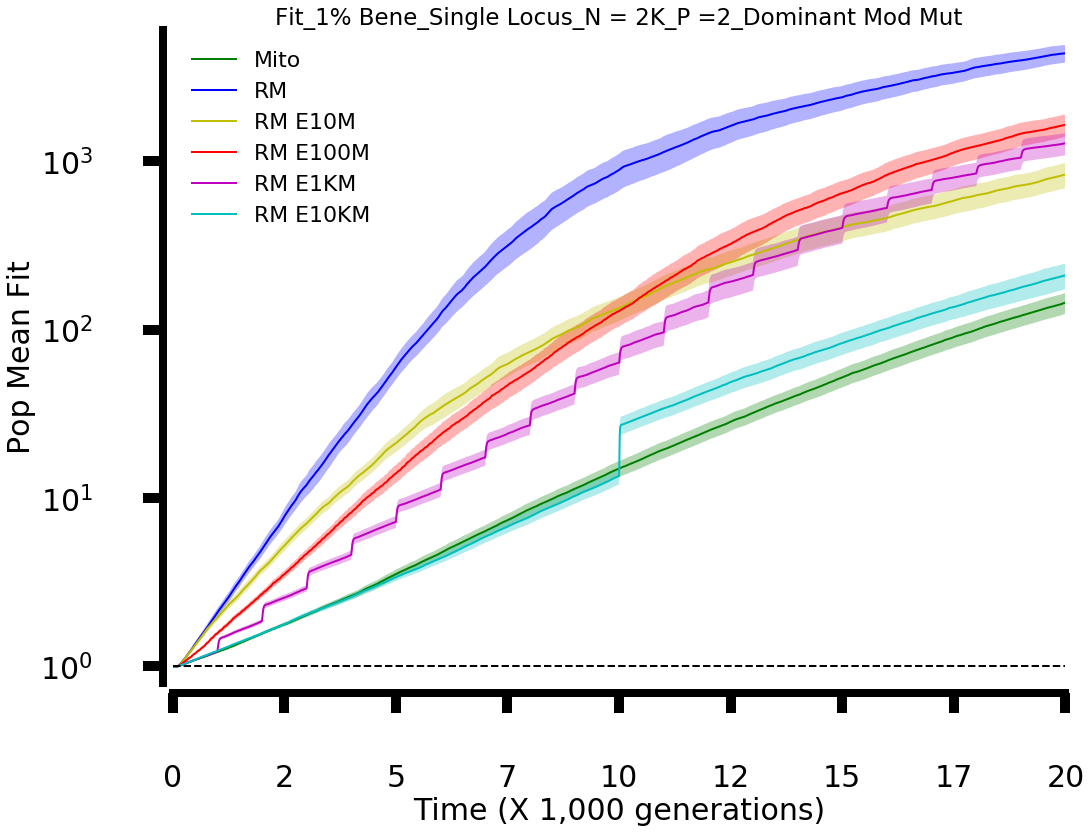

In [23]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,20*1000)

t = generation_list

a1 = f005_fit_mean[0]
error_a1 = list(1.98* np.array(f005_fit_std[0])/((100)**0.5))


a2 = f005_fit_mean[1]
error_a2 = list(1.98* np.array(f005_fit_std[1])/((100)**0.5))


a3 = f005_fit_mean[2]
error_a3 = list(1.98* np.array(f005_fit_std[2])/((100)**0.5))


a4 = f005_fit_mean[3]
error_a4 = list(1.98* np.array(f005_fit_std[3])/((100)**0.5))


a5 = f005_fit_mean[4]
error_a5 = list(1.98* np.array(f005_fit_std[4])/((100)**0.5))

a6 = f005_fit_mean[5]
error_a6 = list(1.98* np.array(f005_fit_std[5])/((100)**0.5))

ax.set_title('Fit_1% Bene_Single Locus_N = 2K_P =2_Dominant Mod Mut', fontsize =23)
ax.set_xlabel('Time (X 1,000 generations)', fontsize =30)
ax.set_ylabel('Pop Mean Fit', fontsize =30)


# ax.semilogy(t, a, )

ax.set_yscale('log')


ax.plot(t,a1,'g', label = 'Mito',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.3, facecolor='g')

ax.plot(t,a2,'b', label = 'RM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.3, facecolor='b')


ax.plot(t,a3,'y', label = 'RM E10M',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.3, facecolor='y')


ax.plot(t,a4,'r', label = 'RM E100M',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a4)- np.array(error_a4), np.array(a4)+ np.array(error_a4), alpha =0.3, facecolor='r')


ax.plot(t,a5,'m', label = 'RM E1KM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a5)- np.array(error_a5), np.array(a5)+ np.array(error_a5), alpha =0.3, facecolor='m')


ax.plot(t,a6,'c', label = 'RM E10KM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a6)- np.array(error_a6), np.array(a6)+ np.array(error_a6), alpha =0.3, facecolor='c')



ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

plt.legend(loc=2, frameon=False, prop={'size':22})

plt.axhline(y=1, linewidth=2.0, color ='k',ls ='dashed')

# extraticks=[0.8, 3000]
# ax.set_yticks(list(ax.get_yticks()) + extraticks)

ax.set_ylim(0.8, 6000)



# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

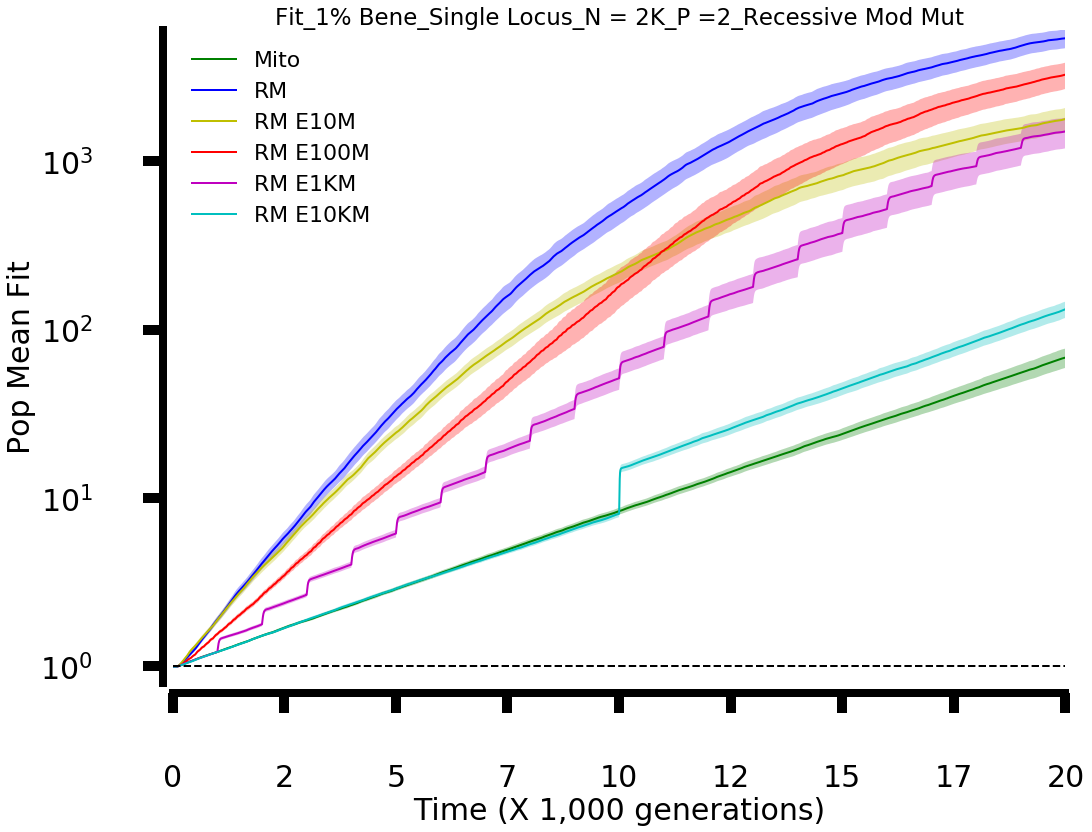

In [28]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,20*1000)

t = generation_list

a1 = f02_fit_mean[0]
error_a1 = list(1.98* np.array(f02_fit_std[0])/((100)**0.5))


a2 = f02_fit_mean[1]
error_a2 = list(1.98* np.array(f02_fit_std[1])/((100)**0.5))


a3 = f02_fit_mean[2]
error_a3 = list(1.98* np.array(f02_fit_std[2])/((100)**0.5))


a4 = f02_fit_mean[3]
error_a4 = list(1.98* np.array(f02_fit_std[3])/((100)**0.5))


a5 = f02_fit_mean[4]
error_a5 = list(1.98* np.array(f02_fit_std[4])/((100)**0.5))

a6 = f02_fit_mean[5]
error_a6 = list(1.98* np.array(f02_fit_std[5])/((100)**0.5))


ax.set_title('Fit_1% Bene_Single Locus_N = 2K_P =2_Recessive Mod Mut', fontsize =23)
ax.set_xlabel('Time (X 1,000 generations)', fontsize =30)
ax.set_ylabel('Pop Mean Fit', fontsize =30)


# ax.semilogy(t, a, )

ax.set_yscale('log')


ax.plot(t,a1,'g', label = 'Mito',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.3, facecolor='g')

ax.plot(t,a2,'b', label = 'RM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.3, facecolor='b')


ax.plot(t,a3,'y', label = 'RM E10M',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.3, facecolor='y')


ax.plot(t,a4,'r', label = 'RM E100M',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a4)- np.array(error_a4), np.array(a4)+ np.array(error_a4), alpha =0.3, facecolor='r')


ax.plot(t,a5,'m', label = 'RM E1KM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a5)- np.array(error_a5), np.array(a5)+ np.array(error_a5), alpha =0.3, facecolor='m')


ax.plot(t,a6,'c', label = 'RM E10KM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a6)- np.array(error_a6), np.array(a6)+ np.array(error_a6), alpha =0.3, facecolor='c')



ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

plt.legend(loc=2, frameon=False, prop={'size':22})

plt.axhline(y=1, linewidth=2.0, color ='k',ls ='dashed')

# extraticks=[0.99]
# ax.set_yticks(list(ax.get_yticks()) + extraticks)

ax.set_ylim(0.8, 6000)



# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

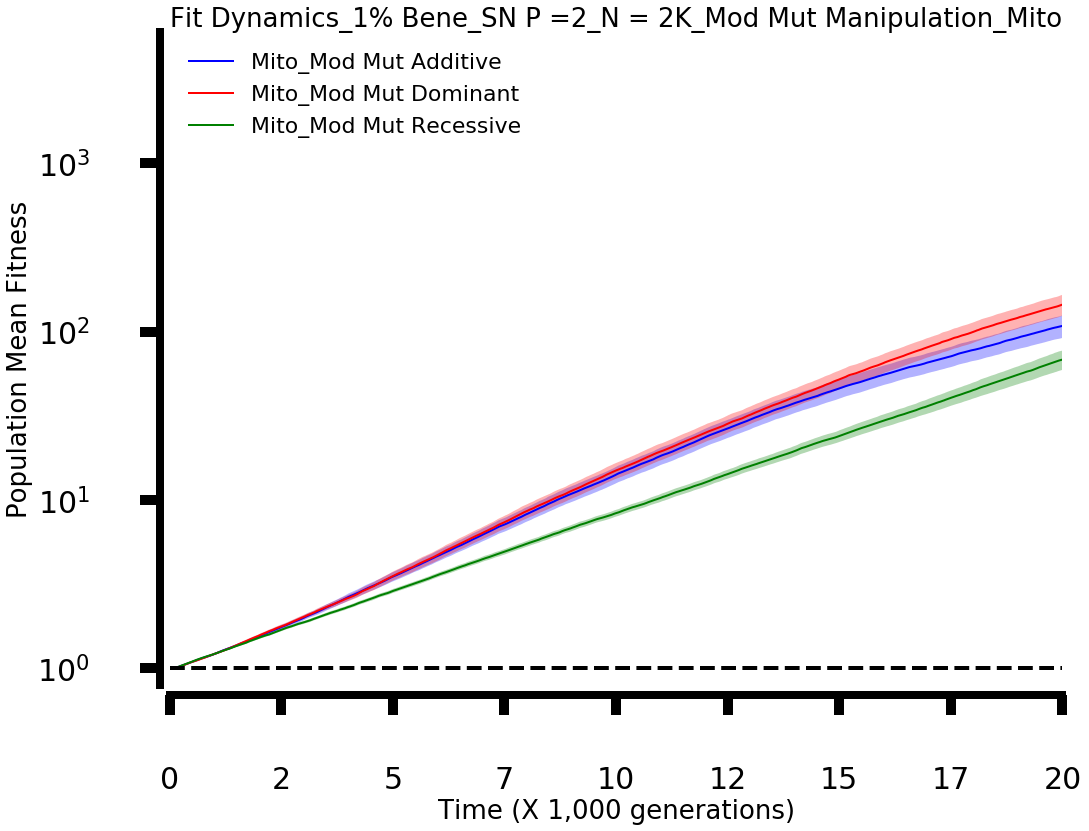

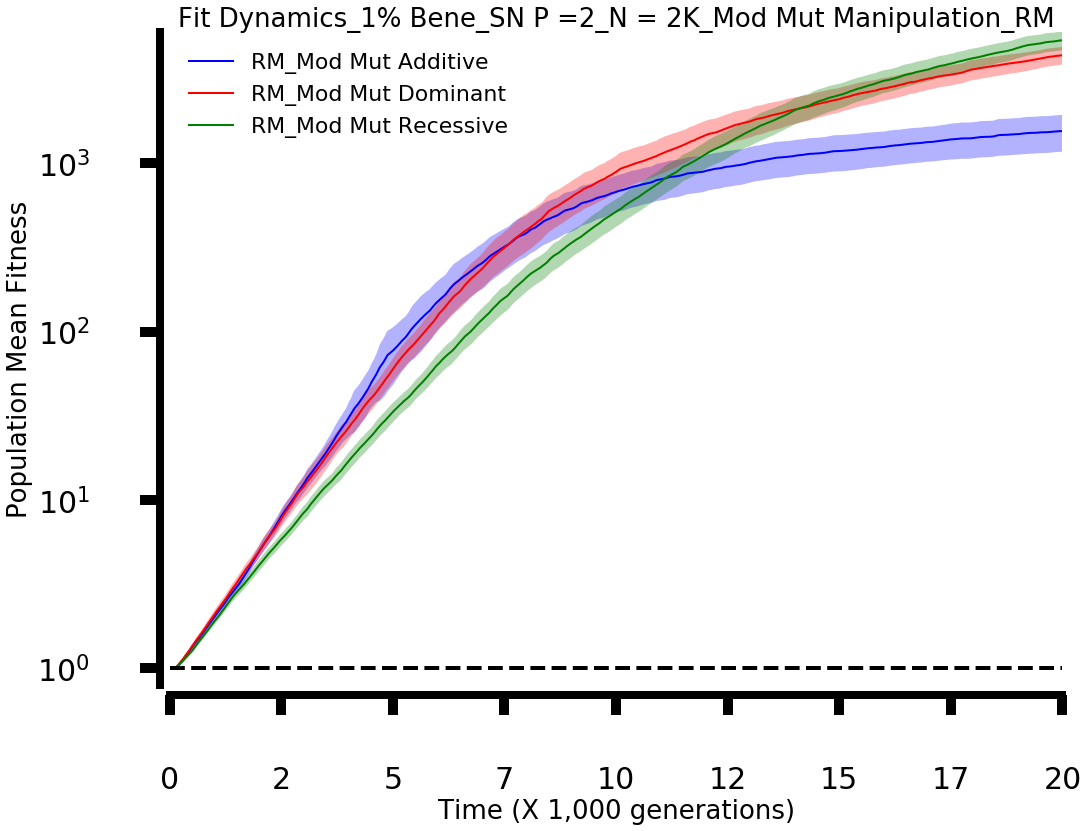

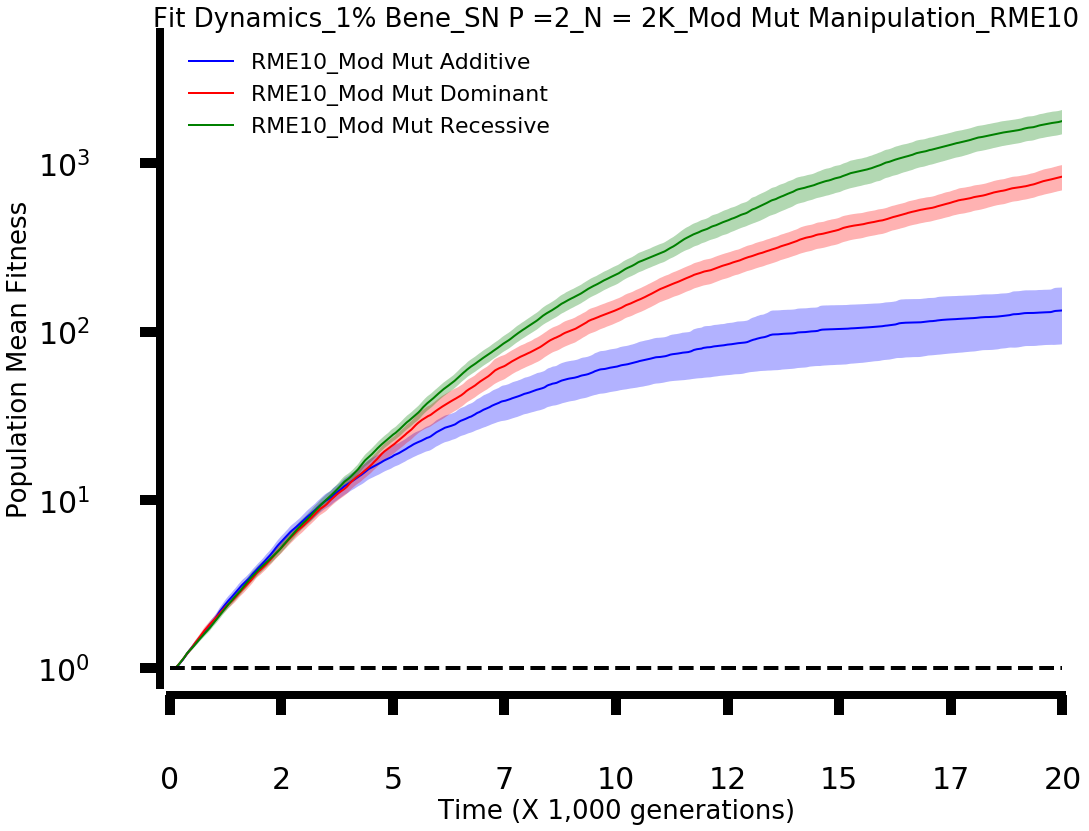

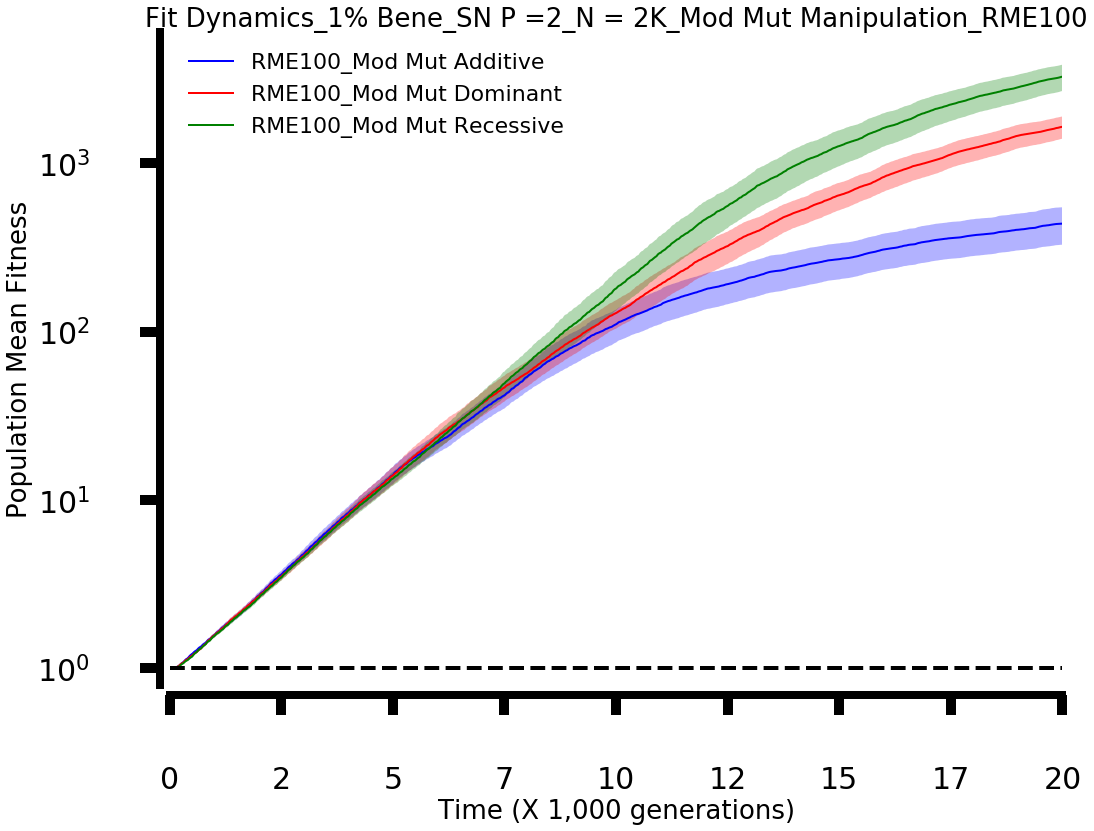

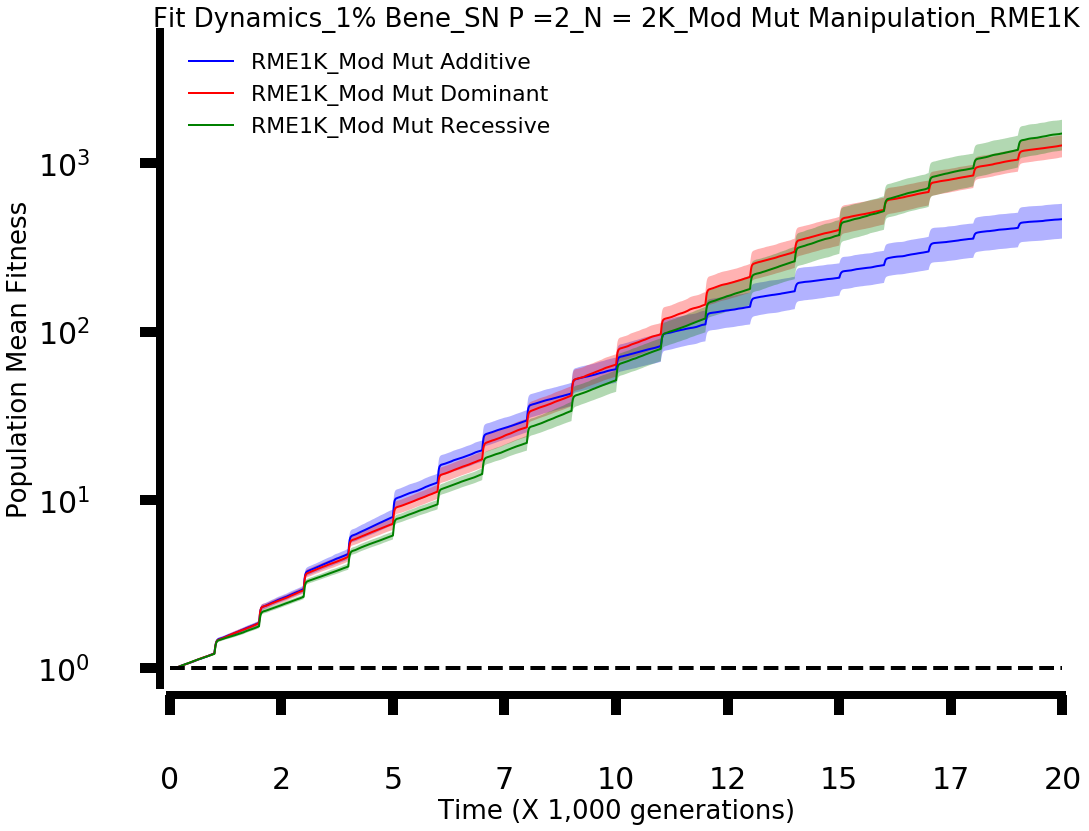

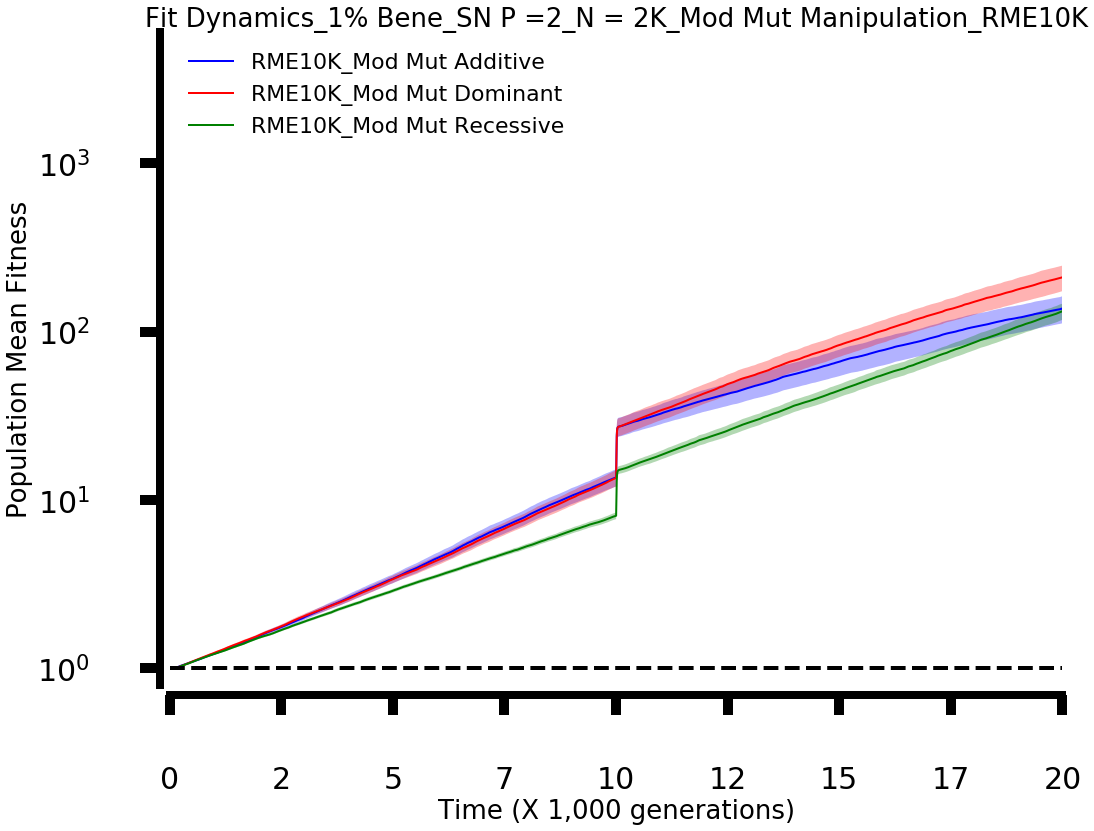

In [31]:
for i in range(6):
    
    
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111)
    publication_figure(ax)
    # ax.scatter(0,0)

    ax.set_xlim(0,20*1000)

    t = generation_list

    a1 = bl_fit_mean[i]
    error_a1 = list(1.98* np.array(bl_fit_std[i])/((100)**0.5))

    a2 = f005_fit_mean[i]
    error_a2 = list(1.98* np.array(f005_fit_std[i])/((100)**0.5))

    a3 = f02_fit_mean[i]
    error_a3 = list(1.98* np.array(f02_fit_std[i])/((100)**0.5))

    

    rp_strategy = ['Mito', 'RM', 'RME10', 'RME100', 'RME1K', 'RME10K']

    ax.set_yscale('log')
    
    ax.set_title('Fit Dynamics_1% Bene_SN P =2_N = 2K_Mod Mut Manipulation_{}'.format(rp_strategy[i]), fontsize =26)
    ax.set_xlabel('Time (X 1,000 generations)', fontsize =26)
    ax.set_ylabel('Population Mean Fitness', fontsize =26)
    
    
    ax.plot(t,a1,'b', label = '{}_Mod Mut Additive'.format(rp_strategy[i]),  linewidth=2.0, alpha =1)
    ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.3, facecolor='b')


    ax.plot(t,a2,'r', label = '{}_Mod Mut Dominant'.format(rp_strategy[i]),  linewidth=2.0, alpha =1)
    ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.3, facecolor='r')


    ax.plot(t,a3,'g', label = '{}_Mod Mut Recessive'.format(rp_strategy[i]),  linewidth=2.0, alpha =1)
    ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.3, facecolor='g')


    plt.axhline(y= 1, linewidth=4.0, color ='k',ls ='dashed')

    ax.minorticks_off()

    plt.legend(loc=2, frameon=False, prop={'size':22})
    
#     extraticks=[0.99]
#     ax.set_yticks(list(ax.get_yticks()) + extraticks)

    ax.set_ylim(0.8, 6000)

    plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

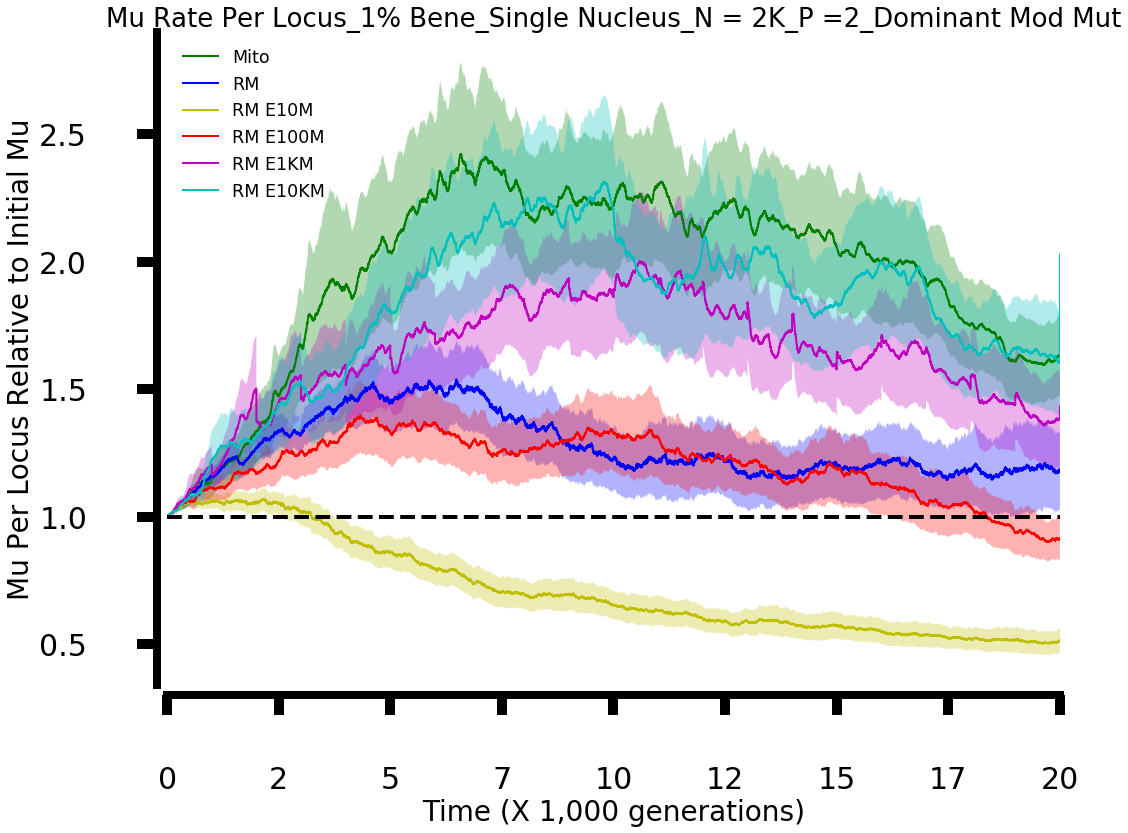

In [38]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,20*1000)

t = generation_list

a1 = np.array(f005_sm_mu_dele_mean[0])/(0.1*2/45/(2*100))
error_a1 = 1.98* np.array(f005_sm_mu_dele_std[0])/((100)**0.5)/(0.1*2/45/(2*100))


a2 = np.array(f005_sm_mu_dele_mean[1])/(0.1*2/45/(2*100))
error_a2 = 1.98* np.array(f005_sm_mu_dele_std[1])/((100)**0.5)/(0.1*2/45/(2*100))


a3 = np.array(f005_sm_mu_dele_mean[2])/(0.1*2/45/(2*100))
error_a3 = 1.98* np.array(f005_sm_mu_dele_std[2])/((100)**0.5)/(0.1*2/45/(2*100))


a4 = np.array(f005_sm_mu_dele_mean[3])/(0.1*2/45/(2*100))
error_a4 = 1.98* np.array(f005_sm_mu_dele_std[3])/((100)**0.5)/(0.1*2/45/(2*100))


a5 = np.array(f005_sm_mu_dele_mean[4])/(0.1*2/45/(2*100))
error_a5 = 1.98* np.array(f005_sm_mu_dele_std[4])/((100)**0.5)/(0.1*2/45/(2*100))


a6 = np.array(f005_sm_mu_dele_mean[5])/(0.1*2/45/(2*100))
error_a6 = 1.98* np.array(f005_sm_mu_dele_std[5])/((100)**0.5)/(0.1*2/45/(2*100))


ax.set_title('Mu Rate Per Locus_1% Bene_Single Nucleus_N = 2K_P =2_Dominant Mod Mut', fontsize =26)
ax.set_xlabel('Time (X 1,000 generations)', fontsize =28)
ax.set_ylabel('Mu Per Locus Relative to Initial Mu', fontsize =28)



ax.plot(t,a1,'g', label = 'Mito',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.3, facecolor='g')

ax.plot(t,a2,'b', label = 'RM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.3, facecolor='b')


ax.plot(t,a3,'y', label = 'RM E10M',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.3, facecolor='y')


ax.plot(t,a4,'r', label = 'RM E100M',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a4)- np.array(error_a4), np.array(a4)+ np.array(error_a4), alpha =0.3, facecolor='r')


ax.plot(t,a5,'m', label = 'RM E1KM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a5)- np.array(error_a5), np.array(a5)+ np.array(error_a5), alpha =0.3, facecolor='m')


ax.plot(t,a6,'c', label = 'RM E10KM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a6)- np.array(error_a6), np.array(a6)+ np.array(error_a6), alpha =0.3, facecolor='c')



plt.axhline(y= (0.1*2/45/(2*100))/(0.1*2/45/(2*100)), linewidth=4.0, color ='k',ls ='dashed')


ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))


plt.legend(loc=2, frameon=False, prop={'size':17.5})

# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

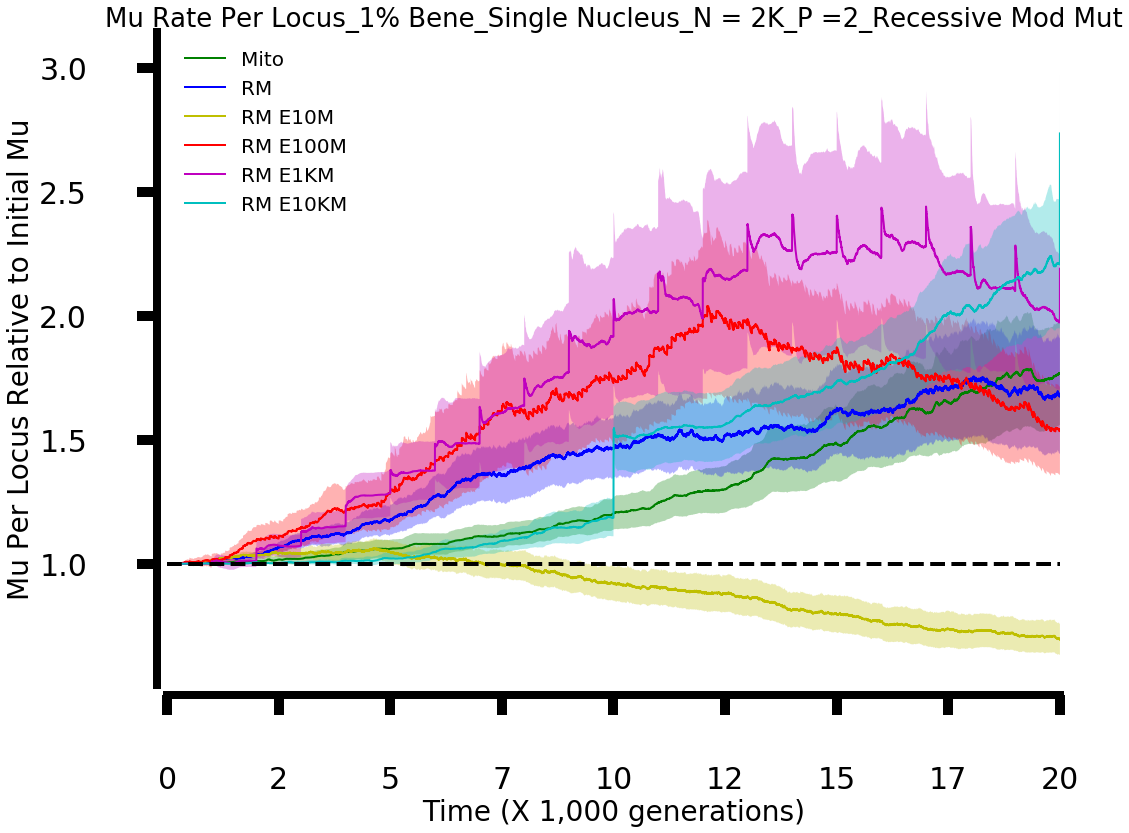

In [40]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,20*1000)

t = generation_list

a1 = np.array(f02_sm_mu_dele_mean[0])/(0.1*2/45/(2*100))
error_a1 = 1.98* np.array(f02_sm_mu_dele_std[0])/((100)**0.5)/(0.1*2/45/(2*100))


a2 = np.array(f02_sm_mu_dele_mean[1])/(0.1*2/45/(2*100))
error_a2 = 1.98* np.array(f02_sm_mu_dele_std[1])/((100)**0.5)/(0.1*2/45/(2*100))


a3 = np.array(f02_sm_mu_dele_mean[2])/(0.1*2/45/(2*100))
error_a3 = 1.98* np.array(f02_sm_mu_dele_std[2])/((100)**0.5)/(0.1*2/45/(2*100))


a4 = np.array(f02_sm_mu_dele_mean[3])/(0.1*2/45/(2*100))
error_a4 = 1.98* np.array(f02_sm_mu_dele_std[3])/((100)**0.5)/(0.1*2/45/(2*100))


a5 = np.array(f02_sm_mu_dele_mean[4])/(0.1*2/45/(2*100))
error_a5 = 1.98* np.array(f02_sm_mu_dele_std[4])/((100)**0.5)/(0.1*2/45/(2*100))


a6 = np.array(f02_sm_mu_dele_mean[5])/(0.1*2/45/(2*100))
error_a6 = 1.98* np.array(f02_sm_mu_dele_std[5])/((100)**0.5)/(0.1*2/45/(2*100))


ax.set_title('Mu Rate Per Locus_1% Bene_Single Nucleus_N = 2K_P =2_Recessive Mod Mut', fontsize =26)
ax.set_xlabel('Time (X 1,000 generations)', fontsize =28)
ax.set_ylabel('Mu Per Locus Relative to Initial Mu', fontsize =28)



ax.plot(t,a1,'g', label = 'Mito',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.3, facecolor='g')

ax.plot(t,a2,'b', label = 'RM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.3, facecolor='b')


ax.plot(t,a3,'y', label = 'RM E10M',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.3, facecolor='y')


ax.plot(t,a4,'r', label = 'RM E100M',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a4)- np.array(error_a4), np.array(a4)+ np.array(error_a4), alpha =0.3, facecolor='r')


ax.plot(t,a5,'m', label = 'RM E1KM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a5)- np.array(error_a5), np.array(a5)+ np.array(error_a5), alpha =0.3, facecolor='m')


ax.plot(t,a6,'c', label = 'RM E10KM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a6)- np.array(error_a6), np.array(a6)+ np.array(error_a6), alpha =0.3, facecolor='c')



plt.axhline(y= (0.1*2/45/(2*100))/(0.1*2/45/(2*100)), linewidth=4.0, color ='k',ls ='dashed')


ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))


plt.legend(loc=2, frameon=False, prop={'size':20})

# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

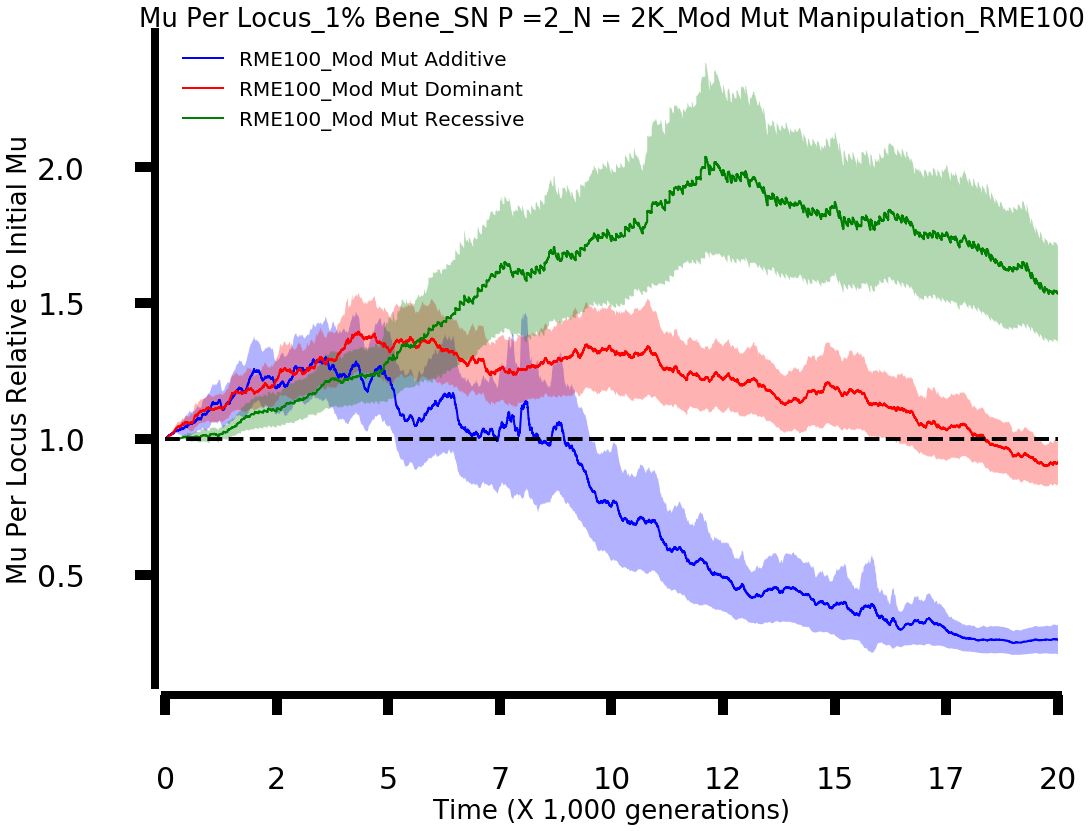

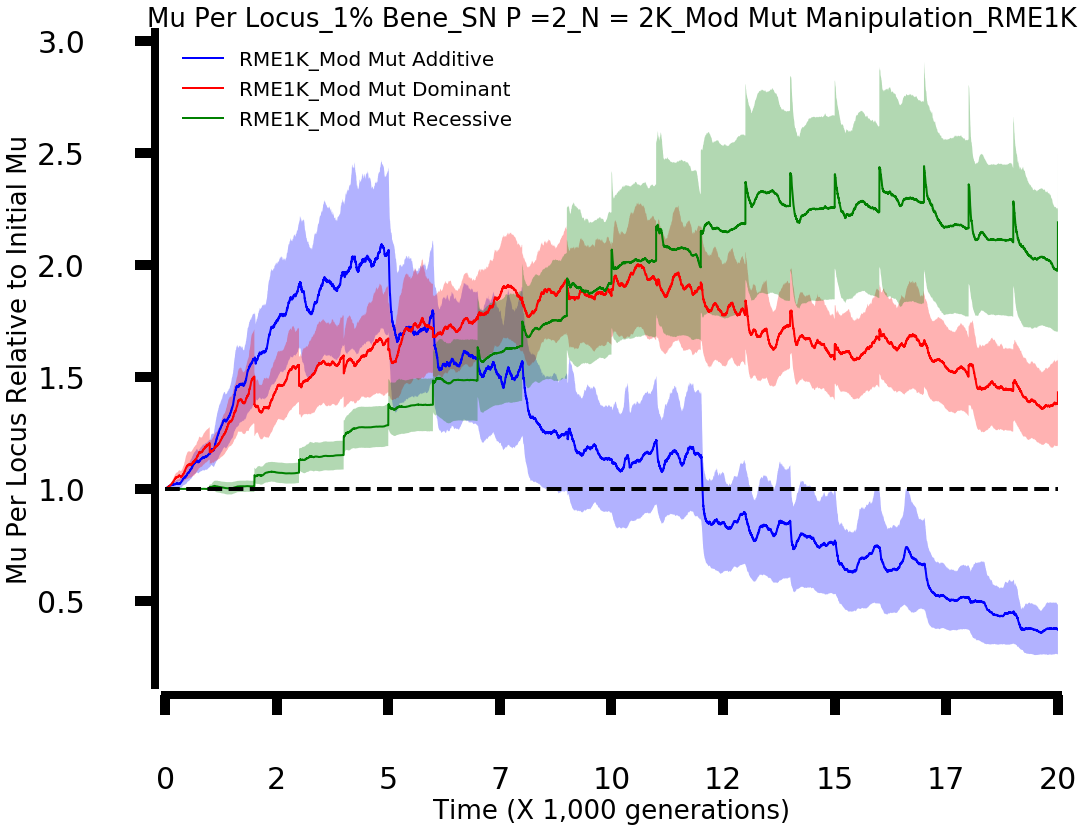

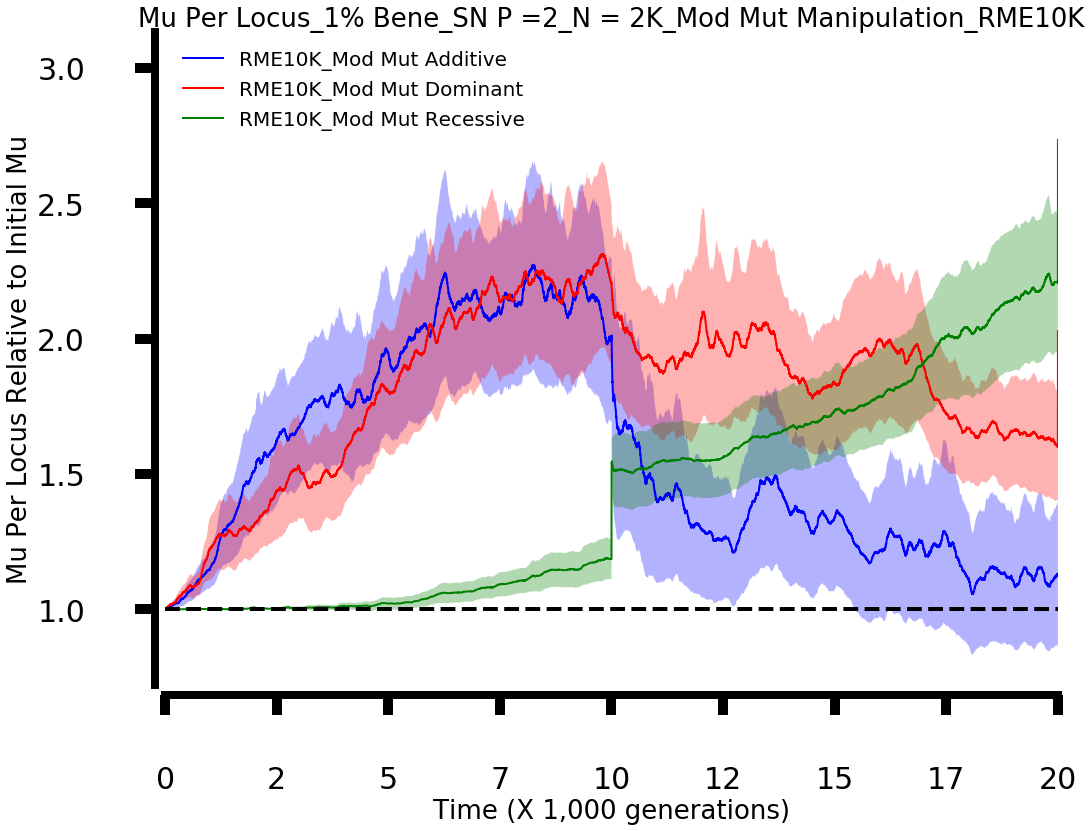

In [44]:
for i in range(3,6):
    
    
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111)
    publication_figure(ax)

    ax.set_xlim(0,20*1000)


    t = generation_list

    a1 = np.array(bl_sm_mu_dele_mean[i])/(0.1*2/45/(2*100))
    error_a1 = 1.98* np.array(bl_sm_mu_dele_std[i])/((100)**0.5)/(0.1*2/45/(2*100))

    a2 = np.array(f005_sm_mu_dele_mean[i])/(0.1*2/45/(2*100))
    error_a2 = 1.98* np.array(f005_sm_mu_dele_std[i])/((100)**0.5)/(0.1*2/45/(2*100))

    a3 = np.array(f02_sm_mu_dele_mean[i])/(0.1*2/45/(2*100))
    error_a3 = 1.98* np.array(f02_sm_mu_dele_std[i])/((100)**0.5)/(0.1*2/45/(2*100))

    rp_strategy = ['Mito', 'RM', 'RME10', 'RME100', 'RME1K', 'RME10K']


    ax.set_title('Mu Per Locus_1% Bene_SN P =2_N = 2K_Mod Mut Manipulation_{}'.format(rp_strategy[i]), fontsize =26)
    ax.set_xlabel('Time (X 1,000 generations)', fontsize =26)
    ax.set_ylabel('Mu Per Locus Relative to Initial Mu', fontsize =26)
    
    
    ax.plot(t,a1,'b', label = '{}_Mod Mut Additive'.format(rp_strategy[i]),  linewidth=2.0, alpha =1)
    ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.3, facecolor='b')


    ax.plot(t,a2,'r', label = '{}_Mod Mut Dominant'.format(rp_strategy[i]),  linewidth=2.0, alpha =1)
    ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.3, facecolor='r')


    ax.plot(t,a3,'g', label = '{}_Mod Mut Recessive'.format(rp_strategy[i]),  linewidth=2.0, alpha =1)
    ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.3, facecolor='g')


    plt.axhline(y= 0.1/(45*100)/(0.1/(45*100)), linewidth=4.0, color ='k',ls ='dashed')

    ax.minorticks_off()

    plt.legend(loc=2, frameon=False, prop={'size':20})
    
    plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

### Check whether the Ctrl Loci have been mutation-fixed

In [45]:
import pickle

In [46]:
def read_file(file_name):
    with open(file_name, 'rb') as f:
        x = pickle.load(f)
        
    return x

In [47]:
def read_file_list(file_list):    
    
    total_x = []
    for i in file_list:
        with open(i, 'rb') as f:
            x = pickle.load(f)
            total_x.append(x)
    return total_x

In [48]:
def check_mut_fix(loci_array, fix_num):
    
    nRep, nInd, nLoci = loci_array[0].shape[0:3]
    
    fix_loci_mean = []
    fix_loci_std = []
    for i in loci_array:
        fix_loci = np.sum(np.sum(i== fix_num,axis=1)==nInd,axis=1)
        fix_loci_mean.append(np.nanmean(fix_loci))
        fix_loci_std.append(np.nanstd(fix_loci))
    
    return fix_loci_mean, fix_loci_std

#### Dominant Mod Mut

In [49]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20200212_Evolution of Mu Rate_Single Locus_1% Bene\Data\1. Diploid\1.2. N2K_1% Bene_Facultative Sex_Dominant Mod")

In [50]:
less_sm_upper_file = ['DominMod_Mito_P2SN_N2K_Bene01_SM_Ctrl_Upper_200207',\
                'DominMod_RM_P2SN_N2K_Bene01_SM_Ctrl_Upper_200207', \
                'DominMod_RME10M_P2SN_N2K_Bene01_SM_Ctrl_Upper_200207', \
                'DominMod_RME100M_P2SN_N2K_Bene01_SM_Ctrl_Upper_200207', \
                'DominMod_RME1KM_P2SN_N2K_Bene01_SM_Ctrl_Upper_200207', \
                'DominMod_RME10KM_P2SN_N2K_Bene01_SM_Ctrl_Upper_200207']

In [51]:
less_sm_lower_file = ['DominMod_Mito_P2SN_N2K_Bene01_SM_Ctrl_Lower_200207',\
                'DominMod_RM_P2SN_N2K_Bene01_SM_Ctrl_Lower_200207', \
                'DominMod_RME10M_P2SN_N2K_Bene01_SM_Ctrl_Lower_200207', \
                'DominMod_RME100M_P2SN_N2K_Bene01_SM_Ctrl_Lower_200207', \
                'DominMod_RME1KM_P2SN_N2K_Bene01_SM_Ctrl_Lower_200207', \
                'DominMod_RME10KM_P2SN_N2K_Bene01_SM_Ctrl_Lower_200207']

In [52]:
less_sm_upper = read_file_list(less_sm_upper_file)
less_sm_lower = read_file_list(less_sm_lower_file)

In [53]:
less_sm_upper_fix = check_mut_fix(less_sm_upper, 2)
less_sm_upper_fix 

([3.1000000000000001,
  1.77,
  0.56000000000000005,
  2.3999999999999999,
  3.8700000000000001,
  3.0099999999999998],
 [2.1142374511865976,
  1.302727907124124,
  0.77871689335727134,
  1.5099668870541501,
  1.968019308848366,
  2.1702304025149037])

In [54]:
less_sm_lower_fix = check_mut_fix(less_sm_lower, 2)
less_sm_lower_fix 

([0.27000000000000002,
  1.3400000000000001,
  1.6699999999999999,
  1.6899999999999999,
  1.98,
  0.52000000000000002],
 [0.50705029336348872,
  0.81510735489259323,
  0.82528782857861183,
  0.94546284961388094,
  1.1311940593903416,
  0.65543878432695768])

In [55]:
def publication_figure2(axis):
    plt.rcParams.update({'font.size': 20})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(4)
    ax.spines['bottom'].set_linewidth(4)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')

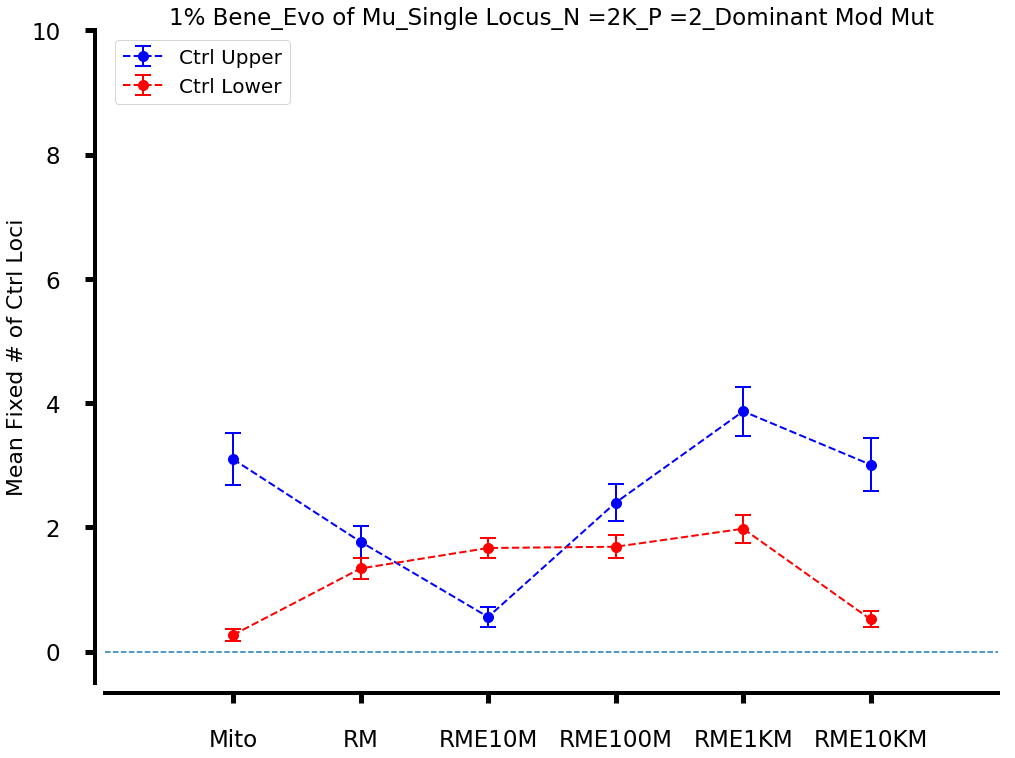

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import pylab

%matplotlib inline

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure2(ax)

mean1 = less_sm_upper_fix [0]
error_bar1 = 1.98*np.array(less_sm_upper_fix[1])/(100**0.5)

mean2 = less_sm_lower_fix [0]
error_bar2 = 1.98*np.array(less_sm_lower_fix[1])/(100**0.5)



plt.errorbar( xrange(6), mean1, yerr=error_bar1, label = 'Ctrl Upper', color = 'b', fmt='o', ls = '--', markersize =10, lw=2, capsize=8, capthick=2)
plt.errorbar( xrange(6), mean2, yerr=error_bar2, label = 'Ctrl Lower', color = 'r', fmt='o', ls = '--', markersize =10, lw=2, capsize=8, capthick=2)


plt.title('1% Bene_Evo of Mu_Single Locus_N =2K_P =2_Dominant Mod Mut', fontsize =23)
plt.ylabel('Mean Fixed # of Ctrl Loci', fontsize =22)
plt.axhline(y=0, xmin=0, xmax=22, ls ='dashed')

 

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

x = range(6)
my_xticks = ['Mito', 'RM', 'RME10M', 'RME100M', 'RME1KM', 'RME10KM']
plt.xticks(x, my_xticks, rotation =0)

plt.tick_params(axis='both', labelsize=23)

plt.legend(loc='upper left')

# legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =15)
# frame = legend.get_frame()
# # frame.set_framecolor('black')
# frame.set_edgecolor('black')


plt.xlim(-1, 6)
plt.ylim(-0.5, 10)


plt.show()

#### Recessive Mod Mutation

In [57]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20200212_Evolution of Mu Rate_Single Locus_1% Bene\Data\1. Diploid\1.3. N2K_1% Bene_Facultative Sex_Recessive Mod")

In [60]:
more_sm_upper_file = ['ReceMod_Mito_P2SN_N2K_Bene01_SM_Ctrl_Upper_200207',\
                'ReceMod_RM_P2SN_N2K_Bene01_SM_Ctrl_Upper_200207', \
                'ReceMod_RME10M_P2SN_N2K_Bene01_SM_Ctrl_Upper_200207', \
                'ReceMod_RME100M_P2SN_N2K_Bene01_SM_Ctrl_Upper_200207', \
                'ReceMod_RME1KM_P2SN_N2K_Bene01_SM_Ctrl_Upper_200207', \
                'ReceMod_RME10KM_P2SN_N2K_Bene01_SM_Ctrl_Upper_200207']

In [61]:
more_sm_lower_file = ['ReceMod_Mito_P2SN_N2K_Bene01_SM_Ctrl_Lower_200207',\
                'ReceMod_RM_P2SN_N2K_Bene01_SM_Ctrl_Lower_200207', \
                'ReceMod_RME10M_P2SN_N2K_Bene01_SM_Ctrl_Lower_200207', \
                'ReceMod_RME100M_P2SN_N2K_Bene01_SM_Ctrl_Lower_200207', \
                'ReceMod_RME1KM_P2SN_N2K_Bene01_SM_Ctrl_Lower_200207', \
                'ReceMod_RME10KM_P2SN_N2K_Bene01_SM_Ctrl_Lower_200207']

In [62]:
more_sm_upper = read_file_list(more_sm_upper_file)
more_sm_lower = read_file_list(more_sm_lower_file)

In [63]:
more_sm_upper_fix = check_mut_fix(more_sm_upper, 2)
more_sm_upper_fix 

([1.3400000000000001,
  2.1400000000000001,
  0.69999999999999996,
  3.2200000000000002,
  3.8300000000000001,
  2.1699999999999999],
 [1.4086873322352267,
  1.3116401945655676,
  0.78102496759066553,
  1.9928873525616044,
  2.4085472800009553,
  1.5300653580811507])

In [64]:
more_sm_lower_fix = check_mut_fix(more_sm_lower, 2)
more_sm_lower_fix 

([0.16,
  1.1000000000000001,
  1.3899999999999999,
  1.55,
  1.6699999999999999,
  0.33000000000000002],
 [0.36660605559646725,
  0.95393920141694577,
  0.83540409383722813,
  0.97339611669658932,
  1.0588200980336555,
  0.49101934788763668])

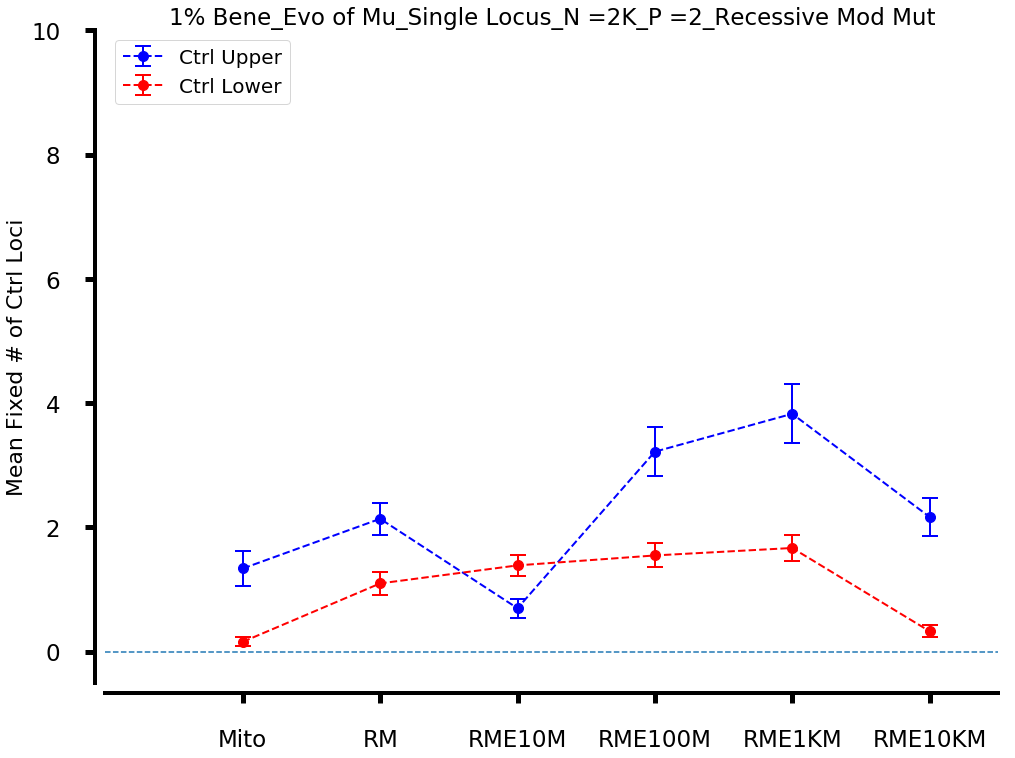

In [67]:
import matplotlib.pyplot as plt
import numpy as np
import pylab

%matplotlib inline

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure2(ax)

mean1 = more_sm_upper_fix [0]
error_bar1 = 1.98*np.array(more_sm_upper_fix[1])/(100**0.5)

mean2 = more_sm_lower_fix [0]
error_bar2 = 1.98*np.array(more_sm_lower_fix[1])/(100**0.5)



plt.errorbar( xrange(6), mean1, yerr=error_bar1, label = 'Ctrl Upper', color = 'b', fmt='o', ls = '--', markersize =10, lw=2, capsize=8, capthick=2)
plt.errorbar( xrange(6), mean2, yerr=error_bar2, label = 'Ctrl Lower', color = 'r', fmt='o', ls = '--', markersize =10, lw=2, capsize=8, capthick=2)


plt.title('1% Bene_Evo of Mu_Single Locus_N =2K_P =2_Recessive Mod Mut', fontsize =23)
plt.ylabel('Mean Fixed # of Ctrl Loci', fontsize =22)
plt.axhline(y=0, xmin=0, xmax=22, ls ='dashed')

 

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

x = range(6)
my_xticks = ['Mito', 'RM', 'RME10M', 'RME100M', 'RME1KM', 'RME10KM']
plt.xticks(x, my_xticks, rotation =0)

plt.tick_params(axis='both', labelsize=23)

plt.legend(loc='upper left')

# legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =15)
# frame = legend.get_frame()
# # frame.set_framecolor('black')
# frame.set_edgecolor('black')


plt.xlim(-1, 5.5)
plt.ylim(-0.5, 10)


plt.show()